# K Means Clustering 

In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('income.csv')
df.head()

,Name,Age,income ($)
0,Najir,27,70000
1,Meraj,29,90000
2,Harkesh,29,61000
3,Lav,28,60000
4,Laxman,42,150000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         22 non-null     object
 1   Age          22 non-null     int64 
 2    income ($)  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


In [6]:
df.columns

Index(['Name', 'Age', ' income ($)'], dtype='object')

Text(0, 0.5, 'Income')

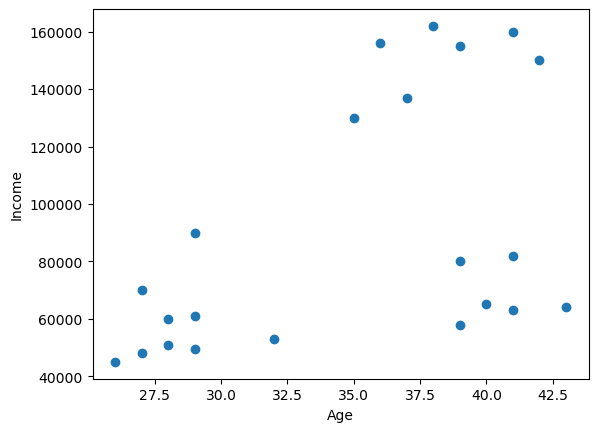

In [8]:
plt.scatter(df.Age,df[' income ($)'])
plt.xlabel('Age')
plt.ylabel('Income')

In [11]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age',' income ($)']])
y_predicted

C:\Users\meraj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0])

In [12]:
df['cluster'] = y_predicted
df.head()

,Name,Age,income ($),cluster
0,Najir,27,70000,0
1,Meraj,29,90000,2
2,Harkesh,29,61000,0
3,Lav,28,60000,0
4,Laxman,42,150000,1


In [13]:
km.cluster_centers_

array([[3.24166667e+01, 5.72916667e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.63333333e+01, 8.40000000e+04]])

In [19]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


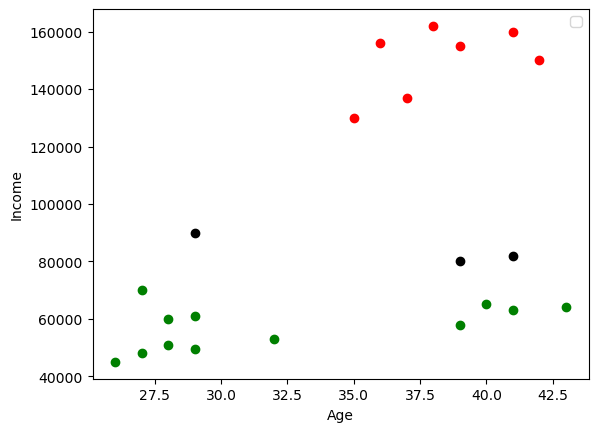

In [20]:
plt.scatter(df1.Age, df1[' income ($)'], color='green')
plt.scatter(df2.Age, df2[' income ($)'], color='red')
plt.scatter(df3.Age, df3[' income ($)'], color='black')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

In [24]:
scaler = MinMaxScaler()
scaler.fit(df[[' income ($)']])
df[' income ($)'] = scaler.transform(df[[' income ($)']]) 

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

df.head()

,Name,Age,income ($),cluster
0,Najir,0.058824,0.213675,0
1,Meraj,0.176471,0.384615,2
2,Harkesh,0.176471,0.136752,0
3,Lav,0.117647,0.128205,0
4,Laxman,0.941176,0.897436,1


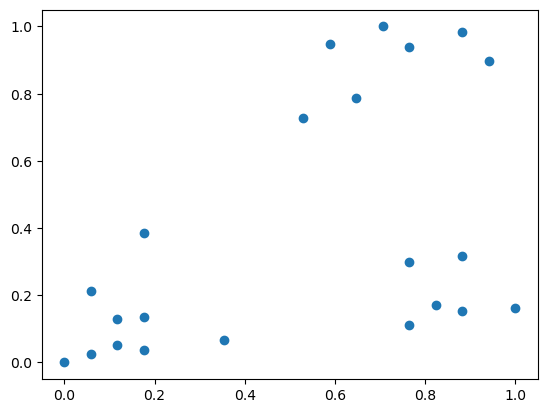

In [25]:
plt.scatter(df.Age,df[' income ($)'])

In [26]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age',' income ($)']])
y_predicted

C:\Users\meraj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2])

In [27]:
df['cluster'] = y_predicted
df.head()

,Name,Age,income ($),cluster
0,Najir,0.058824,0.213675,0
1,Meraj,0.176471,0.384615,0
2,Harkesh,0.176471,0.136752,0
3,Lav,0.117647,0.128205,0
4,Laxman,0.941176,0.897436,1


In [29]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

In [30]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]

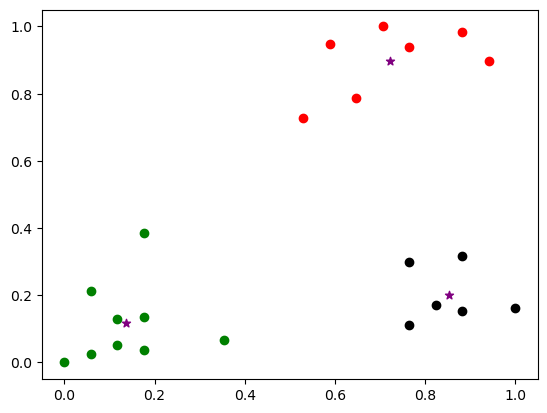

In [34]:
plt.scatter(df1.Age, df1[' income ($)'], color='green')
plt.scatter(df2.Age, df2[' income ($)'], color='red')
plt.scatter(df3.Age, df3[' income ($)'], color='black')

plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')

In [39]:
# Elbow Technique

In [36]:
sse = []

k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age', ' income ($)']])
    sse.append(km.inertia_)

C:\Users\meraj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\meraj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\meraj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\meraj\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

In [37]:
sse

[5.434011511988176,
 2.0911363886990766,
 0.47507834985530945,
 0.4201552205731442,
 0.2664030124668415,
 0.2455595919167622,
 0.19402863836402712,
 0.13976844995388155,
 0.10383752586603559]

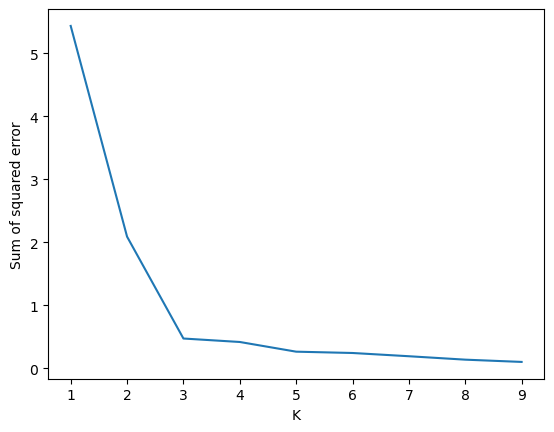

In [38]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)